Using p range: [0.750000, 0.900000]  (N=16)


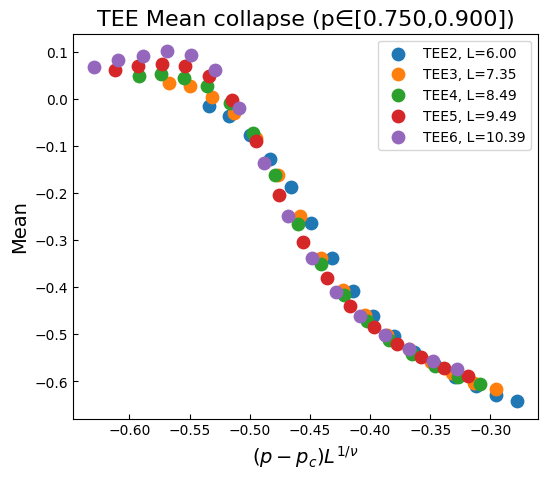

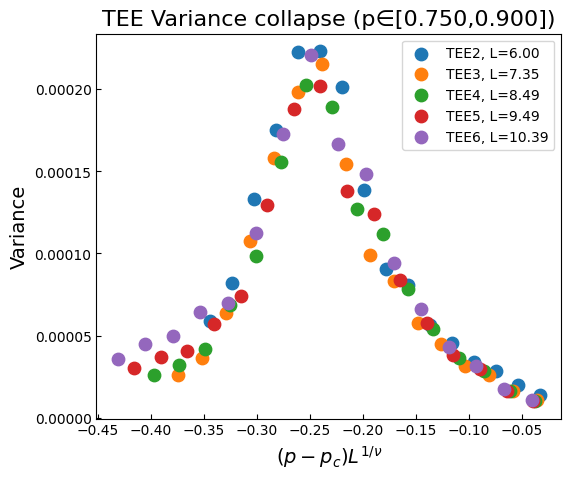

=== 平均 FSS ===
pc = 1.0627573360113876 ± nan
nu = 3.347898237649228 ± nan
zeta = 0.6857890756042422 ± nan
S (mean) = 637.888261946481

=== 分散 FSS ===
pc = 0.9156723568613625 ± 0.3477605179024274
nu = 2.4449993599080226 ± 6.84967570233863
zeta = 4.808918077661353 ± 10.718779524958158
S (var)  = 0.24408881090303164


In [75]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.4

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.75, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.88, nu0=1.7, zeta0=3.9)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.8, nu0=1.7, zeta0=3.75)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))

Using p range: [0.750, 0.880]  (N=14)
Coarse scan best: pc0=0.8713, nu0=1.407, S=0.1845


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


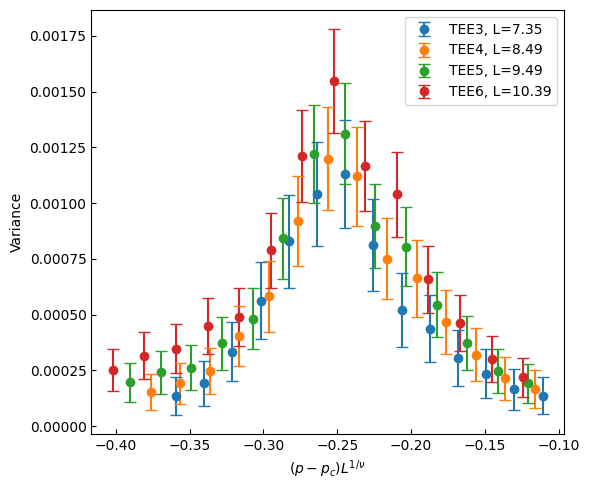


=== Variance FSS ===
pc   = 0.938082 ± 0.267253
nu   = 3.082673 ± 4.847583
zeta = 3.500 (FIXED)
S (var) = 0.5097591626499048


In [87]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力データ
# ======================
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"
#L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ["TEE2", "TEE3", "TEE4", "TEE5", "TEE6"]
L_list   = [ np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ["TEE3", "TEE4", "TEE5", "TEE6"]
# ======================
# 解析条件
# ======================
pc0   = 0.82       # 初期推定の臨界点
width = 0.07       # クリティカル窓の幅
ZETA_VAL = 3.5     # ζ を固定
gamma = 0.5        # 誤差スケール係数

# ======================
# データ読み込み
# ======================
dat = np.load(npz_path)
p_all = dat["pg"]

a_var  = np.array([dat[f"{k}_var"] for k in TEE_keys], dtype=float)
da_src = np.array([dat[f"{k}_err"] for k in TEE_keys], dtype=float)
da_var = da_src * gamma

# --- p 窓を自動設定 ---
mask = (p_all >= pc0 - width) & (p_all <= pc0 + width)
p_use      = p_all[mask]
a_var_sel  = a_var[:,  mask]
da_var_sel = da_var[:, mask]

# --- ソートで順序保証 ---
ordr = np.argsort(p_use)
p_use      = p_use[ordr]
a_var_sel  = a_var_sel[:, ordr]
da_var_sel = da_var_sel[:, ordr]

print(f"Using p range: [{p_use.min():.3f}, {p_use.max():.3f}]  (N={p_use.size})")

# --- 誤差フロア ---
eps = 1e-3 * np.nanmedian(np.abs(a_var_sel))
da_var_sel = np.maximum(da_var_sel, eps)

# ======================
# 粗探索で初期値を作る
# ======================
rhos = np.linspace(p_use.min(), p_use.max(), 31)
nus  = np.linspace(0.8, 3.0, 30)
best = (np.inf, None, None)

for rh in rhos:
    for nv in nus:
        xs, ys, dys = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel, rh, nv, ZETA_VAL)
        S = fssa.quality(xs, ys, dys)
        if S < best[0]:
            best = (S, rh, nv)

rho_c0, nu0 = best[1], best[2]
print(f"Coarse scan best: pc0={rho_c0:.4f}, nu0={nu0:.3f}, S={best[0]:.4f}")

# ======================
# 本番 autoscale
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=rho_c0, nu0=nu0, zeta0=ZETA_VAL)
# ζ 固定
ret_var.zeta  = ZETA_VAL
ret_var.dzeta = 0.0

# スケーリングデータ
xs_var, ys_var, dys_var = fssa.scaledata(
    L_list, p_use, a_var_sel, da_var_sel,
    ret_var.rho, ret_var.nu, ret_var.zeta
)

# ======================
# 可視化
# ======================
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.errorbar(xs_var.T[:, i], ys_var.T[:, i], yerr=dys_var.T[:, i],
                fmt='o', capsize=4,label=f"{key}, L={L:.2f}")
ax.set_xlabel(r"$(p-p_c)L^{1/\nu}$")
ax.set_ylabel("Variance")
ax.legend()
plt.tight_layout()
plt.savefig("TEE_variance_collapse.png", dpi=300)
plt.show()

# ======================
# 結果
# ======================
from fssa import quality
print("\n=== Variance FSS ===")
print(f"pc   = {ret_var.rho:.6f} ± {ret_var.drho:.6f}")
print(f"nu   = {ret_var.nu:.6f} ± {ret_var.dnu:.6f}")
print(f"zeta = {ret_var.zeta:.3f} (FIXED)")
print("S (var) =", quality(xs_var, ys_var, dys_var))


pc, nu = 0.9076698212056888 2.2085456586669743  S = 0.09805917562945679


<Figure size 640x480 with 0 Axes>

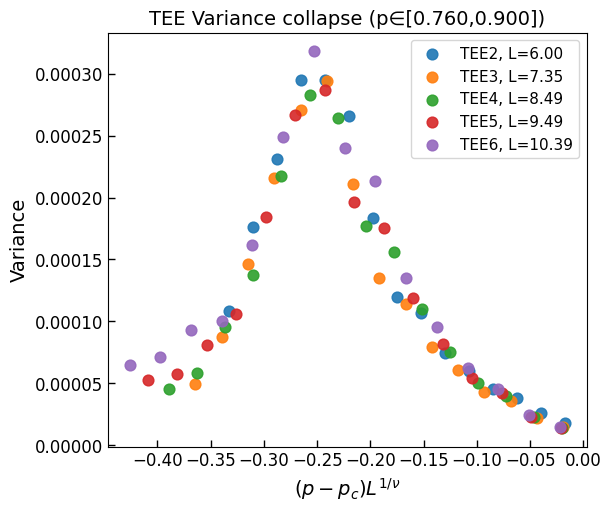

In [63]:
# --- p 窓（A） ---
pc0 = 0.86
width = 0.1
mask = (p_all >= pc0 - width) & (p_all <= pc0 + width)
p_use      = p_all[mask]
a_var_sel  = a_var[:,  mask]
da_var_sel = da_var[:, mask]

# 並び替え（E）
ordr = np.argsort(p_use)
p_use      = p_use[ordr]
a_var_sel  = a_var_sel[:, ordr]
da_var_sel = da_var_sel[:, ordr]

# 誤差フロア（C）
eps = 1e-3 * np.nanmedian(np.abs(a_var_sel))
da_var_sel = np.maximum(da_var_sel, eps)

# ζ 固定（B）
FIX_ZETA = True
ZETA_VAL = 4.0

# 粗探索で初期値（D）
rhos = np.linspace(p_use.min(), p_use.max(), 31)
nus  = np.linspace(0.8, 3.0, 30)
best = (np.inf, None, None)
for rh in rhos:
    for nv in nus:
        xs, ys, dys = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel, rh, nv, ZETA_VAL)
        S = fssa.quality(xs, ys, dys)
        if S < best[0]:
            best = (S, rh, nv)
rho_c0, nu0 = best[1], best[2]

# 本番最適化
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=rho_c0, nu0=nu0, zeta0=ZETA_VAL)
ret_var.zeta  = ZETA_VAL
ret_var.dzeta = 0.0

xs_var, ys_var, dys_var = fssa.scaledata(
    L_list, p_use, a_var_sel, da_var_sel,
    ret_var.rho, ret_var.nu, ret_var.zeta
)
print("pc, nu =", ret_var.rho, ret_var.nu, " S =", fssa.quality(xs_var, ys_var, dys_var))
# ======================
# 可視化（分散のみ）
# ======================
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# L_listとキーの順序を合わせて散布
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i], s=60, alpha=0.9,
               label=f"{key}, L={L:.2f}")

ax.set_xlabel(r"$(p-p_c)L^{1/\nu}$", fontsize=14)
ax.set_ylabel("Variance", fontsize=14)

# 論文向けの見た目
ax.tick_params(direction="in", length=5, width=1, labelsize=12)
ax.legend(fontsize=11, frameon=True)
ax.grid(False)

title = (f"TEE Variance collapse "
         f"(p∈[{p_use.min():.3f},{p_use.max():.3f}])")
ax.set_title(title, fontsize=14)

plt.show()
plt.savefig("TEE_variance_only.png", dpi=300, bbox_inches="tight")
# ===========

In [14]:
# -*- coding: utf-8 -*-
# Peak-shift fit (p_peak(L)=pc + a L^{-1/nu}) + Peak-height fit (Amax ~ L^{zeta/nu})
# 必要: numpy, matplotlib（任意）。SciPy不要。

import numpy as np

# === 入力設定（あなたのデータに合わせて） ===
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"
TEE_keys = ['TEE2','TEE3','TEE4','TEE5','TEE6']   # 使う系列（行）
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]

# どの量でピークを見るか（分散推奨）
TARGET = "var"   # "var" or "ave" など

# === データ読み込み ===
d = np.load(npz_path)
p = d["pg"].astype(float)                 # shape (nP,)
# 量の行列を組む: rows=nL, cols=nP
A = np.array([d[f"{k}_{TARGET}"] for k in TEE_keys], dtype=float)

# === 各Lでピーク位置/高さを推定（3点二次補間で精緻化）===
def quad_vertex(x, y):
    # 3点 (x0,y0),(x1,y1),(x2,y2) から頂点位置を返す。中心点が極大近傍である前提。
    x0,x1,x2 = x
    y0,y1,y2 = y
    denom = (x0-x1)*(x0-x2)*(x1-x2)
    if denom == 0: return x1, y1
    a = (x2*(y1-y0)+x1*(y0-y2)+x0*(y2-y1)) / denom
    b = (x2**2*(y0-y1)+x1**2*(y2-y0)+x0**2*(y1-y2)) / denom
    xv = -b/(2*a) if a != 0 else x1
    yv = a*xv*xv + b*xv + (y0 - a*x0*x0 - b*x0)
    return xv, yv

p_peaks = []
A_peaks = []
for i in range(A.shape[0]):
    yi = A[i]
    j = int(np.argmax(yi))
    # 端ならそのまま、内部なら3点で二次補間
    if 0 < j < len(p)-1:
        xv, yv = quad_vertex(p[j-1:j+2], yi[j-1:j+2])
        # 補間が範囲外に飛んだら元の最大を採用
        if (xv < p[j-1]) or (xv > p[j+1]):
            xv, yv = p[j], yi[j]
    else:
        xv, yv = p[j], yi[j]
    p_peaks.append(xv); A_peaks.append(abs(yv))  # 念のため絶対値

p_peaks = np.array(p_peaks)  # shape (nL,)
A_peaks = np.array(A_peaks)
L = np.array(L_list, float)

print("[peaks] L      p_peak       A_peak")
for Li, pp, ap in zip(L, p_peaks, A_peaks):
    print(f"         {Li:6.3f}  {pp:9.6f}   {ap:.6g}")

# === (1) p_peak(L) = pc + a * L^{-1/nu} で (pc,nu) を決める ===
# nu をグリッド走査し、X=L^{-1/nu} に対して p_peak ~ pc + a X を最小二乗
nu_grid = np.linspace(1.0, 3.0, 401)   # 必要なら範囲/刻みを調整
best = None  # (SSE, nu, pc, a)
for nu in nu_grid:
    X = L**(-1.0/nu)
    # 線形回帰: p_peak = pc + a*X
    Xmat = np.column_stack([np.ones_like(X), X])
    coef, *_ = np.linalg.lstsq(Xmat, p_peaks, rcond=None)
    pc, a = coef
    resid = p_peaks - (pc + a*X)
    sse = np.sum(resid**2)
    if (best is None) or (sse < best[0]):
        best = (sse, nu, pc, a)

sse, nu_hat, pc_hat, a_hat = best
print("\n=== Peak-shift fit ===")
print(f"pc ≈ {pc_hat:.6f}")
print(f"nu ≈ {nu_hat:.6f}  (from p_peak shift)")
print(f"SSE_shift = {sse:.3e}")

# 粗い誤差の当たりを出したければ、LのLOOジャックナイフ:
pcs, nus = [], []
for i_out in range(L.size):
    idx = np.arange(L.size) != i_out
    Li, ppi = L[idx], p_peaks[idx]
    best_i = None
    for nu in nu_grid:
        Xi = Li**(-1.0/nu)
        Xmat = np.column_stack([np.ones_like(Xi), Xi])
        coef, *_ = np.linalg.lstsq(Xmat, ppi, rcond=None)
        pc_i, a_i = coef
        sse_i = np.sum((ppi - (pc_i + a_i*Xi))**2)
        if (best_i is None) or (sse_i < best_i[0]):
            best_i = (sse_i, nu, pc_i)
    pcs.append(best_i[2]); nus.append(best_i[1])

def jackknife_se(vals):
    vals = np.asarray(vals, float)
    n = vals.size
    mean = vals.mean()
    se = np.sqrt((n-1)/n * np.sum((vals-mean)**2))
    return mean, se

pc_mean, pc_se = jackknife_se(pcs)
nu_mean, nu_se = jackknife_se(nus)
print("\n[JACKKNIFE over L]")
print(f"pc = {pc_mean:.6f} ± {pc_se:.6f}")
print(f"nu = {nu_mean:.6f} ± {nu_se:.6f}")

# === (2) ピーク高さ: A_peak(L) ~ L^{zeta/nu} → 傾き s = zeta/nu ===
# log-log で線形回帰
mask_pos = (A_peaks > 0)
logL = np.log(L[mask_pos]); logA = np.log(A_peaks[mask_pos])
M = np.column_stack([np.ones_like(logL), logL])
b, *_ = np.linalg.lstsq(M, logA, rcond=None)  # logA ≈ b0 + s logL
s = b[1]  # s = zeta/nu
zeta_hat = s * nu_hat

# LのLOOジャックナイフ（s と zeta）:
ss = []
for i_out in range(logL.size):
    idx = np.arange(logL.size) != i_out
    Mi = np.column_stack([np.ones_like(logL[idx]), logL[idx]])
    bi, *_ = np.linalg.lstsq(Mi, logA[idx], rcond=None)
    ss.append(bi[1])
s_mean, s_se = jackknife_se(ss)
zeta_mean = s_mean * nu_mean
# ざっくり誤差伝播（cov無視の近似）
zeta_se = np.sqrt( (nu_mean*s_se)**2 + (s_mean*nu_se)**2 )

print("\n=== Peak-height fit ===")
print(f"s = zeta/nu ≈ {s_mean:.6f} ± {s_se:.6f}")
print(f"zeta ≈ {zeta_mean:.6f} ± {zeta_se:.6f}  (using nu from shift)")


[peaks] L      p_peak       A_peak
          6.000   0.795107   0.00766346
          7.348   0.807205   0.0110408
          8.485   0.812764   0.013752
          9.487   0.816801   0.0172028
         10.392   0.819692   0.0220718

=== Peak-shift fit ===
pc ≈ 0.853488
nu ≈ 1.000000  (from p_peak shift)
SSE_shift = 1.384e-06

[JACKKNIFE over L]
pc = 0.855031 ± 0.004827
nu = 1.055000 ± 0.220000

=== Peak-height fit ===
s = zeta/nu ≈ 1.872427 ± 0.150731
zeta ≈ 1.975411 ± 0.441562  (using nu from shift)
